In [1]:
import pandas as pd
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
merged_df = pd.read_csv('data/merged_df.csv')

In [3]:
merged_df['ND_GAIN_class'] = pd.cut(merged_df['ND_GAIN'],
                                    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
                                    labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                                    include_lowest=True)

In [4]:
from itables import show
show(merged_df)

Loading ITables v2.6.2 from the internet... (need help?)


In [5]:
merged_df_2010 = merged_df[merged_df['Year'] == 2010]


In [6]:
# Map ISO3 codes to match world map dataset
# Create a copy to avoid modifying the original dataframe
merged_df_2010_mapped = merged_df_2010.copy()

# Define mappings: ND-GAIN ISO3 -> World Map ISO3
iso3_mappings = {
    'SCG': ['MNE', 'SRB'],  # Serbia and Montenegro -> Montenegro and Serbia
    'ISR': ['PSE'],  # Israel -> Palestine (additional mapping)
    'SDN': ['SSD'],  # Sudan -> South Sudan (additional mapping)
    'CHN': ['TWN']   # China -> Taiwan (additional mapping)
}

# For each mapping, duplicate rows with the new ISO3 codes
additional_rows = []
for source_iso3, target_iso3_list in iso3_mappings.items():
    source_data = merged_df_2010_mapped[merged_df_2010_mapped['ISO3'] == source_iso3]
    if not source_data.empty:
        for target_iso3 in target_iso3_list:
            new_rows = source_data.copy()
            new_rows['ISO3'] = target_iso3
            additional_rows.append(new_rows)

# Concatenate all additional rows to the dataframe
if additional_rows:
    merged_df_2010_mapped = pd.concat([merged_df_2010_mapped] + additional_rows, ignore_index=True)

print(f"Original rows: {len(merged_df_2010)}")
print(f"Rows after mapping: {len(merged_df_2010_mapped)}")

Original rows: 182
Rows after mapping: 187


In [7]:
show(merged_df_2010_mapped)

Loading ITables v2.6.2 from the internet... (need help?)


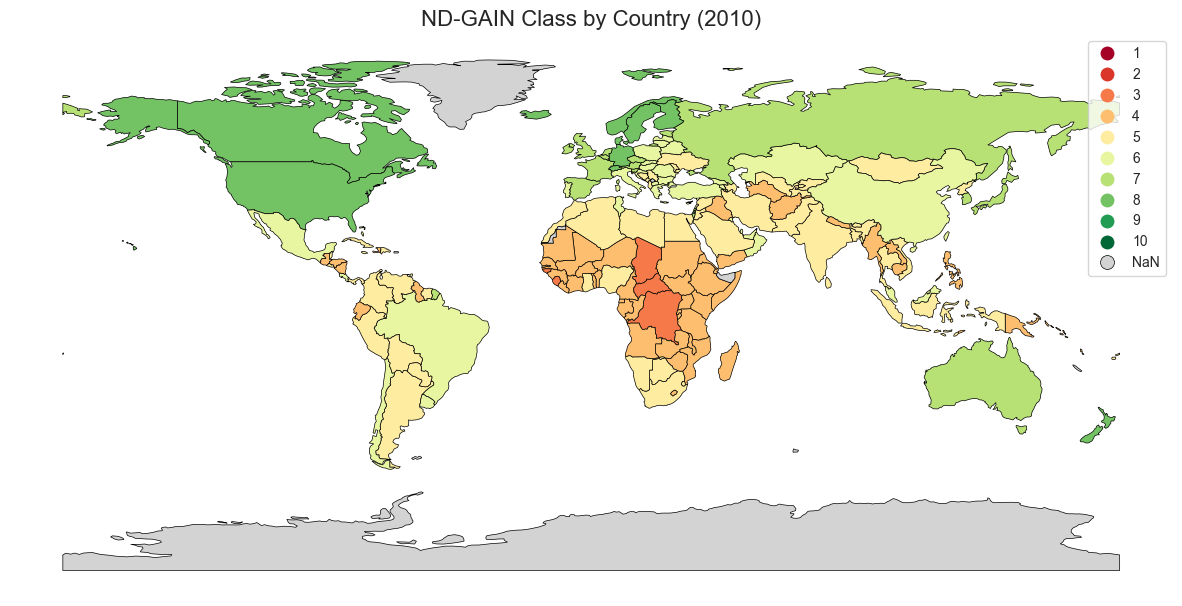

In [8]:
# Load world geometry data directly from Natural Earth
url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
world = gpd.read_file(url)

# Use ISO_A3_EH instead of ISO_A3 (ISO_A3_EH has better coverage)
# Merge the world geometry with the MAPPED data based on ISO3 codes
world_merged = world.merge(merged_df_2010_mapped, left_on='ISO_A3_EH', right_on='ISO3', how='left')

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world_merged.plot(column='ND_GAIN_class', 
                  ax=ax, 
                  legend=True,
                  cmap='RdYlGn',
                  edgecolor='black',
                  linewidth=0.5,
                  missing_kwds={'color': 'lightgrey'})
ax.set_title('ND-GAIN Class by Country (2010)', fontsize=16)
ax.axis('off')
plt.show()

In [9]:
# Cross-check ISO3 codes between datasets
iso3_in_ndgain = set(merged_df_2010_mapped['ISO3'].dropna().unique())
iso3_in_world = set(world['ISO_A3_EH'].dropna().unique())

# Find codes in ND-GAIN but not in world map
missing_in_world = sorted(iso3_in_ndgain - iso3_in_world)

# Find codes in world map but not in ND-GAIN
missing_in_ndgain = sorted(iso3_in_world - iso3_in_ndgain)

print(f"Total ISO3 codes in ND-GAIN dataset: {len(iso3_in_ndgain)}")
print(f"Total ISO3 codes in World map dataset: {len(iso3_in_world)}")
print(f"\n{'='*60}")
print(f"ISO3 codes in ND-GAIN but NOT in World map ({len(missing_in_world)}):")
print(missing_in_world)
print(f"\n{'='*60}")
print(f"ISO3 codes in World map but NOT in ND-GAIN ({len(missing_in_ndgain)}):")
print(missing_in_ndgain)

Total ISO3 codes in ND-GAIN dataset: 187
Total ISO3 codes in World map dataset: 175

ISO3 codes in ND-GAIN but NOT in World map (20):
['ATG', 'BHR', 'BRB', 'COM', 'CPV', 'DMA', 'GRD', 'KIR', 'LCA', 'MDV', 'MLT', 'MUS', 'PLW', 'SCG', 'SGP', 'STP', 'SYC', 'TON', 'VCT', 'WSM']

ISO3 codes in World map but NOT in ND-GAIN (8):
['-99', 'ATA', 'ATF', 'ESH', 'FLK', 'GRL', 'NCL', 'PRI']


## Coupling GHG, Vulnerability

Vulnerability wird noch umgepolt, damit es aufsteigt

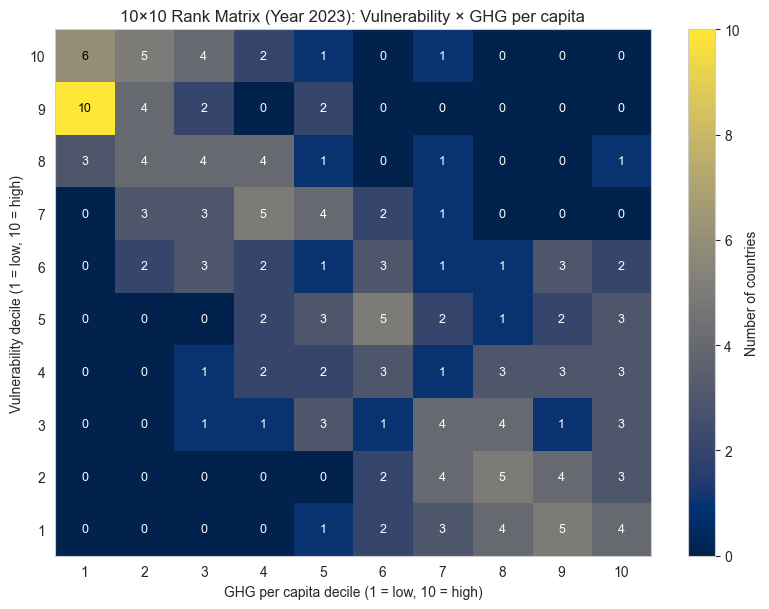

ghg_decile,1,2,3,4,5,6,7,8,9,10
vuln_decile,,,,,,,,,,
1,0,0,0,0,1,2,3,4,5,4
2,0,0,0,0,0,2,4,5,4,3
3,0,0,1,1,3,1,4,4,1,3
4,0,0,1,2,2,3,1,3,3,3
5,0,0,0,2,3,5,2,1,2,3
6,0,2,3,2,1,3,1,1,3,2
7,0,3,3,5,4,2,1,0,0,0
8,3,4,4,4,1,0,1,0,0,1
9,10,4,2,0,2,0,0,0,0,0


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def add_deciles_quantile(dfy: pd.DataFrame, col: str, n_bins: int = 10) -> pd.Series:
    # Wandelt eine kontinuierliche Variable in Rang-basierte Quantile (Deciles) um
    # Wir arbeiten mit Rängen (nicht absoluten Werten), passend zu Spearman/Ranglogik
    # rank(method="first") verhindert Probleme bei vielen gleichen Werten
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


def rank_matrix_10x10(dfy: pd.DataFrame) -> pd.DataFrame:
    # Defensive Kopie, um das Original-DataFrame nicht zu verändern
    dfy = dfy.copy()

    # Emissions-Deciles (1 = niedrige Emissionen, 10 = hohe Emissionen)
    dfy["ghg_decile"] = add_deciles_quantile(dfy, "GHG_per_capita", 10)

    # Vulnerability-Deciles
    # WICHTIG: In deinem Datensatz ist Vulnerability bereits so definiert, dass
    # hohe Werte = hohe Vulnerabilität (z. B. Niger hoch, Schweiz tief).
    # Daher KEINE Inversion hier.
    dfy["vuln_decile"] = add_deciles_quantile(dfy, "Vulnerability", 10)

    # Erzeuge eine 10×10-Rangmatrix (Wert = Anzahl Länder)
    mat = (
        dfy.pivot_table(
            index="vuln_decile",
            columns="ghg_decile",
            values="ISO3",
            aggfunc="nunique",
            fill_value=0
        )
        .reindex(index=range(1, 11), columns=range(1, 11), fill_value=0)
        .astype(int)
    )

    return mat


def plot_rank_matrix(mat: pd.DataFrame, year: int, cmap: str = "cividis") -> None:
    fig, ax = plt.subplots(figsize=(8.2, 6.2))

    # Wichtig gegen "weisses Grid" durch Rendering-Artefakte:
    # origin="lower" => y-Achse: 1 unten, 10 oben (passt zu Label 1=low, 10=high)
    im = ax.imshow(
        mat.values,
        cmap=cmap,
        aspect="auto",
        origin="lower",
        interpolation="none",
        resample=False
    )

    ax.set_title(f"10×10 Rank Matrix (Year {year}): Vulnerability × GHG per capita")
    ax.set_xlabel("GHG per capita decile (1 = low, 10 = high)")
    ax.set_ylabel("Vulnerability decile (1 = low, 10 = high)")

    ax.set_xticks(np.arange(10))
    ax.set_yticks(np.arange(10))
    ax.set_xticklabels(range(1, 11))
    ax.set_yticklabels(range(1, 11))

    # Kein Grid
    ax.grid(False)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Number of countries")

    # Textfarbe: weiss auf dunkel (kleine Werte), schwarz auf hell (grosse Werte)
    vmax = mat.values.max() if mat.values.size else 1
    threshold = 0.55 * vmax

    for i in range(10):
        for j in range(10):
            val = int(mat.iat[i, j])
            color = "white" if val <= threshold else "black"
            ax.text(j, i, str(val), ha="center", va="center", color=color, fontsize=9)

    plt.tight_layout()
    plt.show()


def run_rank_matrix(year: int | str = "latest", path: str = "data/merged_df.csv") -> pd.DataFrame:
    df = pd.read_csv(path)

    if year == "latest":
        year = int(df["Year"].max())
    else:
        year = int(year)

    dfy = df[df["Year"] == year].copy()

    mat = rank_matrix_10x10(dfy)
    plot_rank_matrix(mat, year=year, cmap="cividis")

    return mat


# --- Ausführung ---
mat = run_rank_matrix(year="latest", path="data/merged_df.csv")
mat


### Kontrolle Polaritäten Vulnerability über Extremwerte

In [11]:
# Schau dir die Extremwerte an
# Datensatz explizit laden
df = pd.read_csv("data/merged_df.csv")

# Letztes Jahr bestimmen
latest_year = int(df["Year"].max())

# Auf letztes Jahr filtern
dfy = df[df["Year"] == latest_year].copy()

# Extremwerte anschauen
print("HÖCHSTE Vulnerability-Werte:")
display(
    dfy.sort_values("Vulnerability", ascending=False)
       [["Country", "ISO3", "Vulnerability"]]
       .head(15)
)

print("\nNIEDRIGSTE Vulnerability-Werte:")
display(
    dfy.sort_values("Vulnerability", ascending=True)
       [["Country", "ISO3", "Vulnerability"]]
       .head(15)
)



HÖCHSTE Vulnerability-Werte:


,Country,ISO3,Vulnerability
4581,Chad,TCD,0.639627
3450,Niger,NER,0.632981
4233,Solomon Islands,SLB,0.629253
1884,Guinea-Bissau,GNB,0.612813
4146,Sudan and South Sudan,SDN,0.611921
4320,Somalia,SOM,0.610504
4755,Tonga,TON,0.606593
4262,Sierra Leone,SLE,0.597257
1507,Eritrea,ERI,0.591530
28,Afghanistan,AFG,0.587516



NIEDRIGSTE Vulnerability-Werte:


,Country,ISO3,Vulnerability
869,Switzerland,CHE,0.251258
3566,Norway,NOR,0.255615
1246,Czechia,CZE,0.263809
1623,Finland,FIN,0.280200
840,Canada,CAN,0.281584
1739,United Kingdom,GBR,0.288056
2348,"Israel and Palestine, State of",ISR,0.289366
260,Austria,AUT,0.295317
1275,Germany,DEU,0.301489
1681,France,FRA,0.304166


Loading ITables v2.6.2 from the internet... (need help?)


C:\Users\alexi\Alexis\Projects\FHNW\ciCH\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10231 (\N{LONG LEFT RIGHT ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


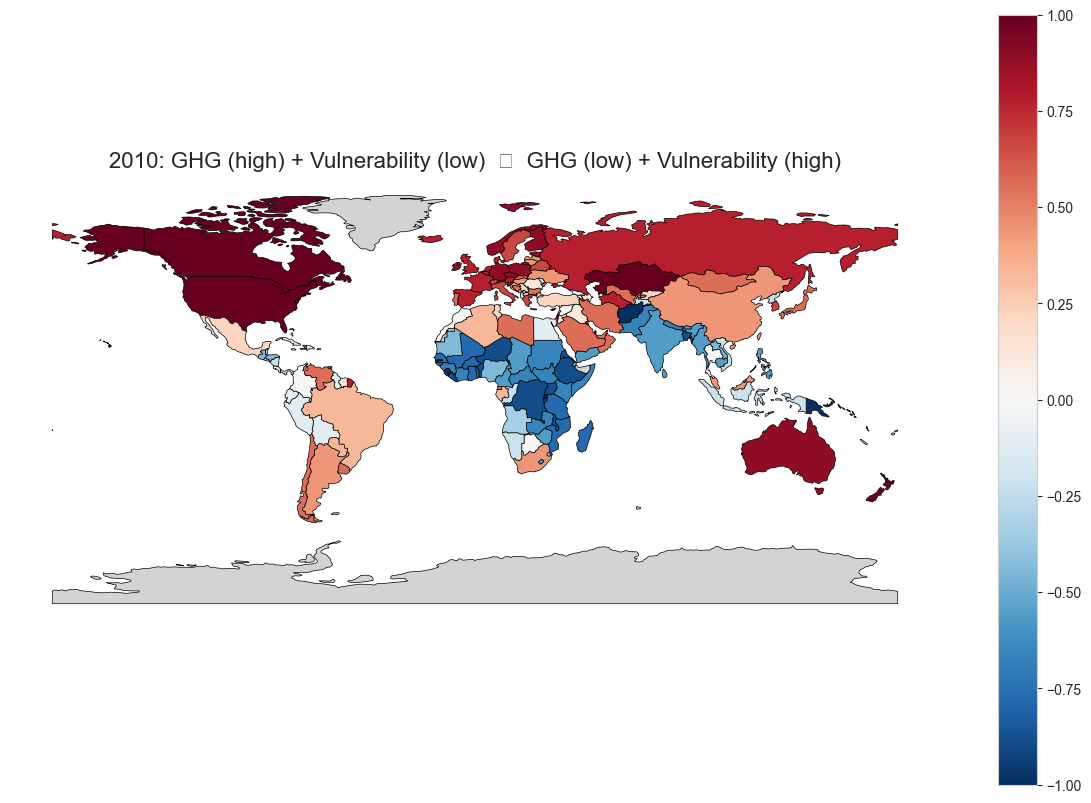

In [12]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from itables import show


def add_deciles_quantile(dfy: pd.DataFrame, col: str, n_bins: int = 10) -> pd.Series:
    # Rang-basierte Deciles, robust bei vielen gleichen Werten
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


# --- 1) Deciles + Kombi-Score auf deinem 2010-Frame erzeugen ---
# Annahme: merged_df_2010_mapped hat Spalten: ISO3, GHG_per_capita, Vulnerability
merged_df_2010_mapped = merged_df_2010_mapped.copy()

# GHG: 1 = low, 10 = high
merged_df_2010_mapped["ghg_decile"] = add_deciles_quantile(merged_df_2010_mapped, "GHG_per_capita", 10)

# Vulnerability: 1 = low, 10 = high (bei dir ist das bereits so orientiert!)
merged_df_2010_mapped["vuln_decile"] = add_deciles_quantile(merged_df_2010_mapped, "Vulnerability", 10)

# Kombi-Index:
# + hoch, wenn GHG hoch UND Vulnerability tief
# - tief, wenn GHG tief UND Vulnerability hoch
merged_df_2010_mapped["ghg_minus_vuln"] = merged_df_2010_mapped["ghg_decile"] - merged_df_2010_mapped["vuln_decile"]
# Wertebereich: -9 ... +9

# Optional: normalisieren auf [-1, +1] (praktisch für Legende/vergleich)
merged_df_2010_mapped["ghg_minus_vuln_norm"] = merged_df_2010_mapped["ghg_minus_vuln"] / 9.0

show(merged_df_2010_mapped)


# --- 2) Welt-Geometrie laden und mergen ---
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world_merged = world.merge(
    merged_df_2010_mapped,
    left_on="ISO_A3_EH",
    right_on="ISO3",
    how="left"
)


# --- 3) Plot: Diverging Colormap (zwei Extreme) ---
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Diverging cmap: negativ = forced-rider Extrem, positiv = free-rider Extrem
# (Du kannst auch "coolwarm" nehmen; das ist ebenfalls diverging.)
world_merged.plot(
    column="ghg_minus_vuln_norm",      # <- der neue Score
    ax=ax,
    legend=True,
    cmap="RdBu_r",                     # blau = negativ, rot = positiv (umgedreht im Zweifel)
    edgecolor="black",
    linewidth=0.5,
    missing_kwds={"color": "lightgrey"},
    vmin=-1, vmax=1                    # symmetrisch, damit 0 = neutral wirklich Mitte ist
)

ax.set_title(
    "2010: GHG (high) + Vulnerability (low)  ⟷  GHG (low) + Vulnerability (high)",
    fontsize=16
)
ax.axis("off")
plt.show()


Loading ITables v2.6.2 from the internet... (need help?)


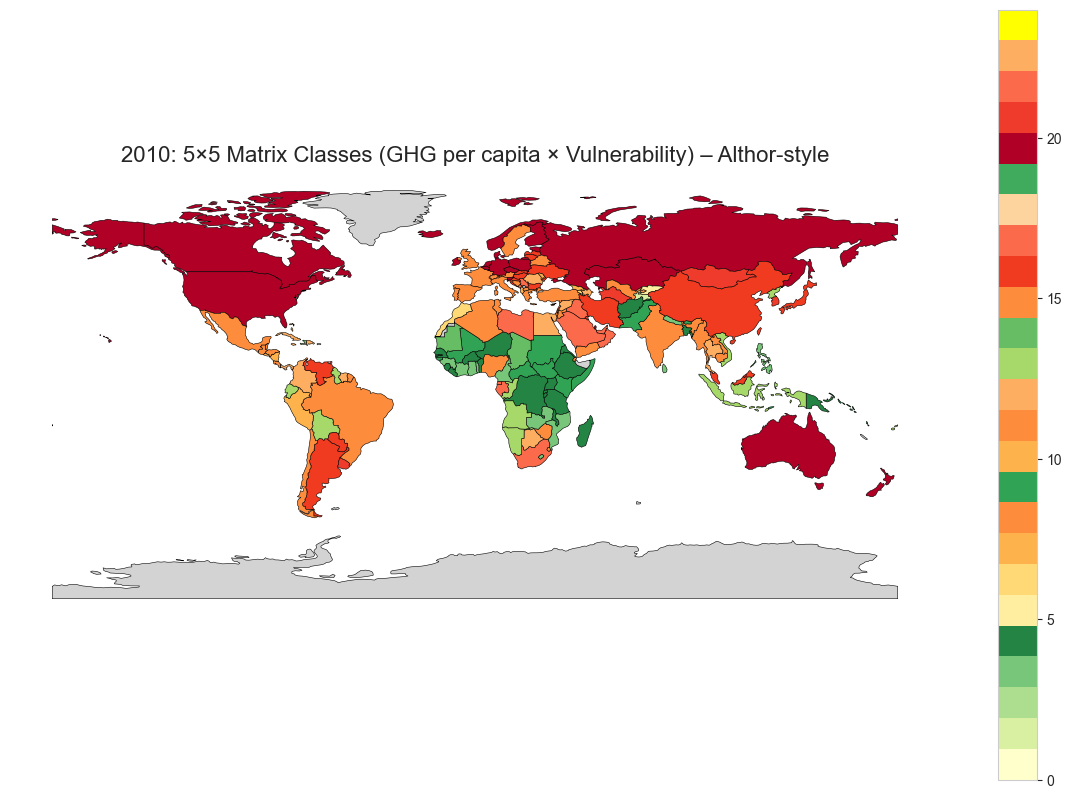

In [13]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from itables import show


def add_quantile_bins(dfy: pd.DataFrame, col: str, n_bins: int = 5) -> pd.Series:
    # Rang-basierte Quantile (robust bei ties)
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


# --- 1) Quintile auf deinem 2010-Frame erzeugen ---
# Achsenlogik wie bei Althor:
#   x: Vulnerability (1 = low, 5 = high)
#   y: Emissions level (1 = low, 5 = high)
df5 = merged_df_2010_mapped.copy()

df5["ghg_q"] = add_quantile_bins(df5, "GHG_per_capita", 5)     # 1..5 (low..high)
df5["vuln_q"] = add_quantile_bins(df5, "Vulnerability", 5)     # 1..5 (low..high)

# Cell-ID: 25 Klassen
# Wir wollen eine eindeutige Klasse pro 5×5-Zelle.
# Reihenfolge (optional): y = ghg_q von low->high, x = vuln_q von low->high
# cell_id in [0..24] (praktisch für colormap)
df5["cell_id"] = (df5["ghg_q"] - 1) * 5 + (df5["vuln_q"] - 1)

# Optional: Für Tabelle sichtbar machen
show(df5[["Country","ISO3","Year","GHG_per_capita","Vulnerability","ghg_q","vuln_q","cell_id"]].head(30))


# --- 2) Althor-ähnliche 5×5 Farbcodes definieren ---
# Idee: Oben links (high GHG, low vuln) = "free rider" = rot/dunkelrot
#       Unten rechts (low GHG, high vuln) = "forced rider" = grün/dunkelgrün
#
# Achtung: Matplotlib colormap läuft von index 0..24.
# Unser cell_id ist so aufgebaut:
#   ghg_q steigt nach unten im Array (row-major), vuln_q nach rechts.
# Farbmatrix bauen wir aber bewusst als 5×5 "logical grid":
# rows = ghg_q low->high, cols = vuln_q low->high
#
# Du kannst die Farben später 1:1 feinjustieren.

# 5x5 Farben: rot -> gelb -> grün (Althor-like)
# row 0 = low emissions, row 4 = high emissions
# col 0 = low vulnerability, col 4 = high vulnerability
color_grid = np.array([
    ["#ffffcc", "#d9f0a3", "#addd8e", "#78c679", "#238443"],  # low ghg
    ["#ffeda0", "#fed976", "#feb24c", "#fd8d3c", "#31a354"],
    ["#feb24c", "#fd8d3c", "#fdae61", "#a6d96a", "#66bd63"],
    ["#fd8d3c", "#f03b20", "#fb6a4a", "#fdd49e", "#41ab5d"],
    ["#b10026", "#ef3b2c", "#fb6a4a", "#fdae61", "#ffff00"],  # high ghg (links rot)
], dtype=object)

# Hinweis:
# In Althor ist "free rider" oben links (high ghg, low vuln).
# Unser grid hat high ghg in der letzten Zeile (row 4), low vuln in col 0.
# Damit free rider "row 4, col 0" rot wird, muss die letzte Zeile links rot sein.
# forced rider (low ghg, high vuln) = row 0, col 4 = grün -> passt.

# In ListedColormap muss es eine flache Liste sein, in der Reihenfolge cell_id 0..24:
# cell_id = (ghg_q-1)*5 + (vuln_q-1) => row-major
cmap_althor = ListedColormap(color_grid.reshape(-1).tolist())


# --- 3) Welt-Geometrie laden und mergen ---
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world_merged = world.merge(
    df5,
    left_on="ISO_A3_EH",
    right_on="ISO3",
    how="left"
)


# --- 4) Plot: diskrete 25 Klassen (5×5) statt Streifen ---
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

world_merged.plot(
    column="cell_id",
    ax=ax,
    legend=True,
    cmap=cmap_althor,
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={"color": "lightgrey"},
    vmin=0, vmax=24
)

ax.set_title("2010: 5×5 Matrix Classes (GHG per capita × Vulnerability) – Althor-style", fontsize=16)
ax.axis("off")
plt.show()


C:\Users\alexi\AppData\Local\Temp\ipykernel_47472\1801699419.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


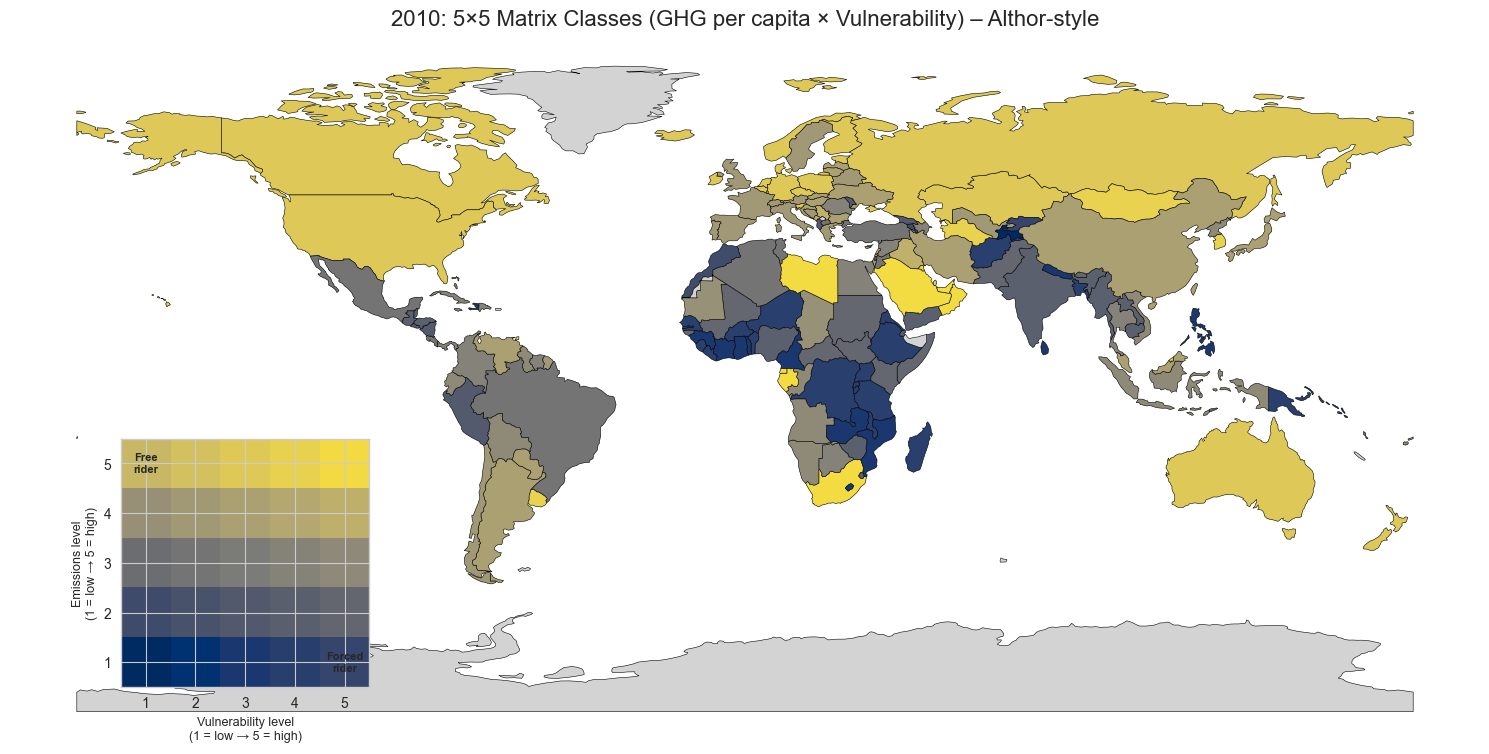

In [14]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def add_quantile_bins(dfy: pd.DataFrame, col: str, n_bins: int = 5) -> pd.Series:
    # Rang-basierte Quantile (robust bei ties)
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


def make_5x5_cmap(base_cmap_name: str = "cividis") -> tuple[ListedColormap, np.ndarray]:
    """
    Erzeugt eine diskrete 25-Farben-Map aus einem farbenblind-tauglichen Continuous-Cmap.
    Gleichzeitig wird eine 5×5-Farbmatrix zurückgegeben (für die inset-Legende).
    """
    base = plt.get_cmap(base_cmap_name)

    # 25 diskrete Farben gleichmässig aus der Continuous-Cmap sampeln
    colors = [base(x) for x in np.linspace(0.05, 0.95, 25)]
    cmap25 = ListedColormap(colors)

    # In 5×5 Rasterform bringen (row-major)
    color_grid = np.arange(25).reshape(5, 5)  # Werte 0..24, nur fuer Legendenbild
    return cmap25, color_grid


# --- 1) Quintile + 25 Klassen (wie Althor: 5×5) ---
df5 = merged_df_2010_mapped.copy()

# Achsenlogik wie bei Althor:
# x: Vulnerability (1 = low, 5 = high)
# y: Emissions level (1 = low, 5 = high)
df5["ghg_q"] = add_quantile_bins(df5, "GHG_per_capita", 5)   # 1..5
df5["vuln_q"] = add_quantile_bins(df5, "Vulnerability", 5)   # 1..5

# cell_id: 0..24 (row-major)
# row = ghg_q-1 (low->high), col = vuln_q-1 (low->high)
df5["cell_id"] = (df5["ghg_q"] - 1) * 5 + (df5["vuln_q"] - 1)


# --- 2) Welt-Geometrie mergen ---
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world_merged = world.merge(
    df5,
    left_on="ISO_A3_EH",
    right_on="ISO3",
    how="left"
)


# --- 3) Colormap: farbenblind-tauglich (Blau–Gelb) ---
# Empfehlung: "cividis" (sehr gut für Farbblindheit), alternativ: "viridis"
cmap25, legend_grid = make_5x5_cmap(base_cmap_name="cividis")


# --- 4) Plot: Karte OHNE Streifen-Colorbar + Inset 5×5 Farbmatrix ---
fig, ax = plt.subplots(1, 1, figsize=(15, 9))

world_merged.plot(
    column="cell_id",
    ax=ax,
    cmap=cmap25,
    edgecolor="black",
    linewidth=0.4,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("2010: 5×5 Matrix Classes (GHG per capita × Vulnerability) – Althor-style", fontsize=16)
ax.axis("off")


# --- 5) Inset: 5×5 Farbmatrix-Legende (wie im Paper) ---
# Inset-Achse platzieren (links unten wie Althor; bei Bedarf bbox_to_anchor anpassen)
ax_leg = inset_axes(
    ax,
    width="22%", height="35%",
    loc="lower left",
    bbox_to_anchor=(0.05, 0.08, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

# 5×5 Matrix anzeigen (origin="lower" => unten = low emissions, oben = high emissions)
im_leg = ax_leg.imshow(
    legend_grid,
    cmap=cmap25,
    origin="lower",
    interpolation="none"
)

# Achsenticks/Labels wie Althor
ax_leg.set_xticks(range(5))
ax_leg.set_yticks(range(5))
ax_leg.set_xticklabels([1, 2, 3, 4, 5])
ax_leg.set_yticklabels([1, 2, 3, 4, 5])

ax_leg.set_xlabel("Vulnerability level\n(1 = low → 5 = high)", fontsize=9)
ax_leg.set_ylabel("Emissions level\n(1 = low → 5 = high)", fontsize=9)

# Optional: Ecken labels (Free/Forced) wie im Paper
# Althor: Free rider = high emissions + low vulnerability => (y=5, x=1) => top-left
# Forced rider = low emissions + high vulnerability => (y=1, x=5) => bottom-right
ax_leg.text(0, 4, "Free\nrider", ha="center", va="center", fontsize=8, fontweight="bold")
ax_leg.text(4, 0, "Forced\nrider", ha="center", va="center", fontsize=8, fontweight="bold")

# Rahmen klar machen
for spine in ax_leg.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.show()


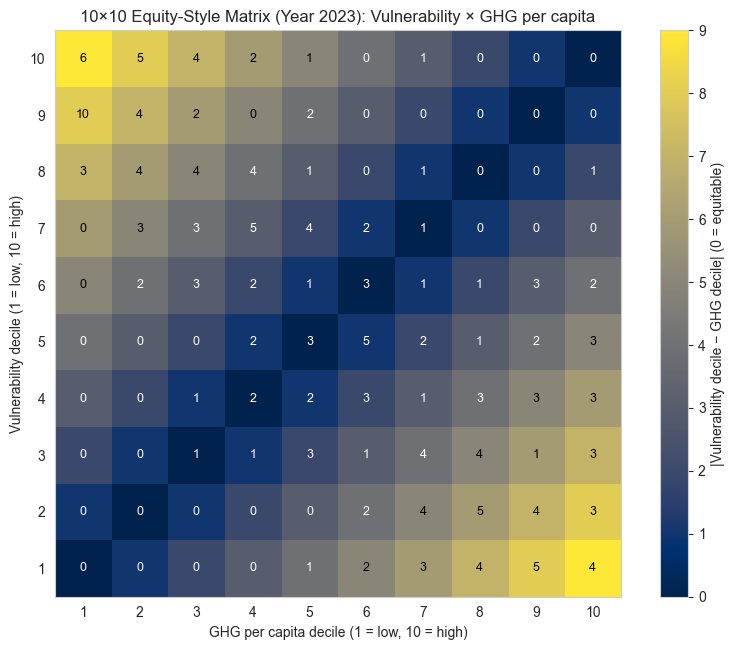

ghg_decile,1,2,3,4,5,6,7,8,9,10
vuln_decile,,,,,,,,,,
1,0,0,0,0,1,2,3,4,5,4
2,0,0,0,0,0,2,4,5,4,3
3,0,0,1,1,3,1,4,4,1,3
4,0,0,1,2,2,3,1,3,3,3
5,0,0,0,2,3,5,2,1,2,3
6,0,2,3,2,1,3,1,1,3,2
7,0,3,3,5,4,2,1,0,0,0
8,3,4,4,4,1,0,1,0,0,1
9,10,4,2,0,2,0,0,0,0,0


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def add_deciles_quantile(dfy: pd.DataFrame, col: str, n_bins: int = 10) -> pd.Series:
    # Rang-basierte Deciles (robust bei ties)
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


def compute_deciles(dfy: pd.DataFrame) -> pd.DataFrame:
    """
    Erzeugt ghg_decile und vuln_decile (je 1..10, low..high) und gibt dfy zurück.
    Annahme: Vulnerability ist bereits so orientiert, dass hohe Werte = hohe Vulnerabilität.
    """
    dfy = dfy.copy()
    dfy["ghg_decile"] = add_deciles_quantile(dfy, "GHG_per_capita", 10)
    dfy["vuln_decile"] = add_deciles_quantile(dfy, "Vulnerability", 10)
    return dfy


def build_count_matrix_10x10(dfy: pd.DataFrame) -> pd.DataFrame:
    """
    10×10 Matrix: Zeilen = Vulnerability-Deciles (1..10), Spalten = GHG-Deciles (1..10),
    Werte = Anzahl Länder (nunique ISO3).
    """
    mat = (
        dfy.pivot_table(
            index="vuln_decile",
            columns="ghg_decile",
            values="ISO3",
            aggfunc="nunique",
            fill_value=0
        )
        .reindex(index=range(1, 11), columns=range(1, 11), fill_value=0)
        .astype(int)
    )
    return mat


def build_equity_color_matrix_10x10() -> np.ndarray:
    """
    Baut eine 10×10 Farbwert-Matrix im Althor-Sinn, sodass:
    - alle Zellen auf der Diagonale (y=x) denselben Farbw ert haben (Equity-Band)
    - je weiter weg von der Diagonale, desto "extremer" die Farbe

    Wir codieren Farbe über d = (vuln_decile - ghg_decile).
    d < 0 => high GHG & low vuln (Free-rider Richtung)
    d > 0 => low GHG & high vuln (Forced-rider Richtung)
    """
    # d liegt in [-9, +9]
    grid = np.zeros((10, 10), dtype=int)
    for i in range(10):       # i = vuln index 0..9
        for j in range(10):   # j = ghg  index 0..9
            d = (i + 1) - (j + 1)
            grid[i, j] = d
    return grid


def plot_rank_matrix_equity_style(
    counts: pd.DataFrame,
    year: int,
    cmap: str = "cividis",
    show_zeros: bool = True
) -> None:
    """
    Plottet die 10×10 Zählmatrix, aber färbt Zellen nach Distanz zur Diagonale (Equity-Stil),
    sodass die Diagonale überall gleich gefärbt ist.
    Entfernt die weissen Linien (kein Grid, kein Interpolations-Artefakt).
    """
    # Farbwerte: Distanz zur Diagonale als "Ungerechtigkeits-Intensität"
    # dist = |vuln - ghg| => 0..9, Diagonale immer 0 (gleiche Farbe)
    dist = np.abs(build_equity_color_matrix_10x10())  # 10×10, 0..9

    fig, ax = plt.subplots(figsize=(8.4, 6.6))

    # WICHTIG gegen weisse Linien:
    # - interpolation="none"
    # - resample=False
    # - aspect="equal" (quadratische Pixel reduzieren Render-Artefakte)
    # - origin="lower" damit 1 unten, 10 oben
    im = ax.imshow(
        dist,
        cmap=cmap,
        origin="lower",
        interpolation="none",
        resample=False,
        aspect="equal",
        vmin=0,
        vmax=9
    )

    ax.set_title(f"10×10 Equity-Style Matrix (Year {year}): Vulnerability × GHG per capita")
    ax.set_xlabel("GHG per capita decile (1 = low, 10 = high)")
    ax.set_ylabel("Vulnerability decile (1 = low, 10 = high)")

    ax.set_xticks(np.arange(10))
    ax.set_yticks(np.arange(10))
    ax.set_xticklabels(range(1, 11))
    ax.set_yticklabels(range(1, 11))

    # Keine Gitterlinien / keine minor ticks
    ax.grid(False)
    ax.minorticks_off()

    # Colorbar beschreibt jetzt "distance from equity diagonal"
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("|Vulnerability decile − GHG decile| (0 = equitable)")

    # Zellzahlen = Anzahl Länder in dieser (vuln, ghg)-Zelle
    vmax_counts = counts.values.max() if counts.values.size else 1
    threshold = 0.55 * vmax_counts

    for i in range(10):
        for j in range(10):
            val = int(counts.iat[i, j])

            if (not show_zeros) and val == 0:
                continue

            # Textfarbe auf Basis des Hintergrunds (dist): dunkel => weiss, hell => schwarz
            # cividis: low dist eher dunkel -> weiss; high dist eher hell -> schwarz
            # (Wenn du eine andere cmap nimmst und es dreht: einfach Bedingung invertieren.)
            color = "white" if dist[i, j] <= 4 else "black"

            ax.text(j, i, str(val), ha="center", va="center", color=color, fontsize=9)

    plt.tight_layout()
    plt.show()


def run_equity_matrix(
    year: int | str = "latest",
    path: str = "data/merged_df.csv",
    cmap: str = "cividis",
) -> pd.DataFrame:
    df = pd.read_csv(path)

    if year == "latest":
        year = int(df["Year"].max())
    else:
        year = int(year)

    dfy = df[df["Year"] == year].copy()
    dfy = compute_deciles(dfy)

    counts = build_count_matrix_10x10(dfy)
    plot_rank_matrix_equity_style(counts, year=year, cmap=cmap, show_zeros=True)

    return counts


# --- Ausführung ---
counts = run_equity_matrix(year="latest", path="data/merged_df.csv", cmap="cividis")
counts


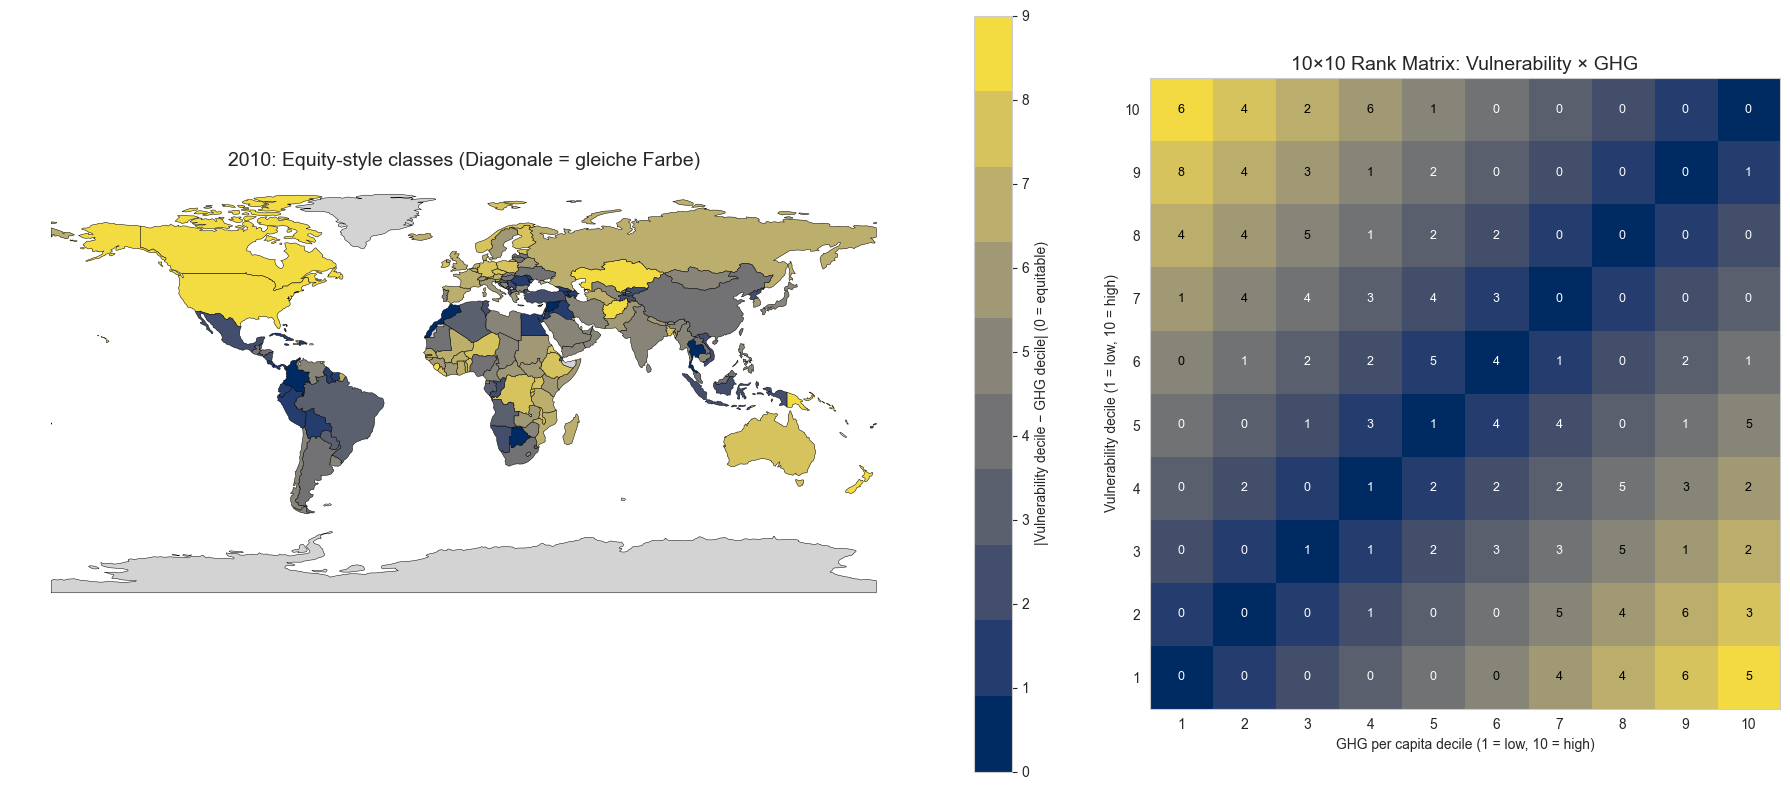

ghg_decile,1,2,3,4,5,6,7,8,9,10
vuln_decile,,,,,,,,,,
1,0,0,0,0,0,0,4,4,6,5
2,0,0,0,1,0,0,5,4,6,3
3,0,0,1,1,2,3,3,5,1,2
4,0,2,0,1,2,2,2,5,3,2
5,0,0,1,3,1,4,4,0,1,5
6,0,1,2,2,5,4,1,0,2,1
7,1,4,4,3,4,3,0,0,0,0
8,4,4,5,1,2,2,0,0,0,0
9,8,4,3,1,2,0,0,0,0,1


In [16]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def add_deciles_quantile(dfy: pd.DataFrame, col: str, n_bins: int = 10) -> pd.Series:
    # Rang-basierte Deciles (robust bei ties)
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


def compute_deciles(dfy: pd.DataFrame) -> pd.DataFrame:
    """
    Erzeugt ghg_decile und vuln_decile (je 1..10, low..high).
    Annahme: Vulnerability ist bereits so orientiert, dass hohe Werte = hohe Vulnerabilität.
    """
    dfy = dfy.copy()
    dfy["ghg_decile"] = add_deciles_quantile(dfy, "GHG_per_capita", 10)   # 1..10
    dfy["vuln_decile"] = add_deciles_quantile(dfy, "Vulnerability", 10)   # 1..10
    return dfy


def build_count_matrix_10x10(dfy: pd.DataFrame) -> pd.DataFrame:
    """
    10×10 Matrix: Zeilen = Vulnerability-Deciles (1..10), Spalten = GHG-Deciles (1..10),
    Werte = Anzahl Länder (nunique ISO3).
    """
    mat = (
        dfy.pivot_table(
            index="vuln_decile",
            columns="ghg_decile",
            values="ISO3",
            aggfunc="nunique",
            fill_value=0
        )
        .reindex(index=range(1, 11), columns=range(1, 11), fill_value=0)
        .astype(int)
    )
    return mat


def equity_distance_grid_10x10() -> np.ndarray:
    """
    dist = |vuln_decile - ghg_decile| in [0..9]
    -> Diagonale überall 0 => gleiche Farbe (Equity-Band)
    """
    grid = np.zeros((10, 10), dtype=int)
    for i in range(10):       # i: vuln index 0..9
        for j in range(10):   # j: ghg  index 0..9
            grid[i, j] = abs((i + 1) - (j + 1))
    return grid


def discrete_cmap_from_continuous(base_cmap: str = "cividis", n: int = 10) -> ListedColormap:
    """
    Baut eine diskrete Colormap mit n Stufen aus einer Continuous-Colormap.
    Für dist=0..9 brauchen wir n=10.
    """
    base = plt.get_cmap(base_cmap)
    colors = [base(x) for x in np.linspace(0.05, 0.95, n)]
    return ListedColormap(colors)


def plot_map_and_matrix_10x10_equity_style(
    df_2010: pd.DataFrame,
    world_url: str = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip",
    cmap_name: str = "cividis"
) -> tuple[pd.DataFrame, gpd.GeoDataFrame]:
    """
    Produziert eine Figure mit:
    - links: Weltkarte nach Equity-Distanz (0..9)
    - rechts: 10×10 Rank-Matrix (Counts) mit gleichem Farbschema (Diagonale gleich)
    """
    dfy = compute_deciles(df_2010)

    # Distanz zur Equity-Diagonale als gemeinsame "Klasse" (0..9)
    dfy["equity_dist"] = (dfy["vuln_decile"] - dfy["ghg_decile"]).abs().astype(int)

    # 10×10 Count-Matrix (für Zahlenanzeige)
    counts = build_count_matrix_10x10(dfy)

    # 10×10 Farbgrid (für Matrix-Färbung)
    dist_grid = equity_distance_grid_10x10()

    # diskrete cmap mit 10 Stufen: 0..9
    cmap10 = discrete_cmap_from_continuous(cmap_name, n=10)

    # World geometry
    world = gpd.read_file(world_url)
    world_merged = world.merge(
        dfy,
        left_on="ISO_A3_EH",
        right_on="ISO3",
        how="left"
    )

    # --- Figure: 1×2 Layout ---
    fig, (ax_map, ax_mat) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.8, 1]})

    # --- A) MAP (keine Colorbar-Streifen: wir machen eine diskrete Legende über Colorbar,
    # aber mit klaren 10 Stufen; wenn du gar keine willst, kann man sie ausblenden)
    world_merged.plot(
        column="equity_dist",
        ax=ax_map,
        cmap=cmap10,
        edgecolor="black",
        linewidth=0.35,
        missing_kwds={"color": "lightgrey"},
        vmin=0, vmax=9,
        legend=True,
        legend_kwds={"label": "|Vulnerability decile − GHG decile| (0 = equitable)"}
    )
    ax_map.set_title("2010: Equity-style classes (Diagonale = gleiche Farbe)", fontsize=14)
    ax_map.axis("off")

    # --- B) MATRIX (gleiches Farbschema, keine weissen Linien) ---
    im = ax_mat.imshow(
        dist_grid,
        cmap=cmap10,
        origin="lower",
        interpolation="none",   # verhindert weisse Kanten durch Interpolation
        resample=False,         # verhindert Resampling-Artefakte
        aspect="equal",
        vmin=0, vmax=9
    )

    ax_mat.set_title("10×10 Rank Matrix: Vulnerability × GHG", fontsize=14)
    ax_mat.set_xlabel("GHG per capita decile (1 = low, 10 = high)")
    ax_mat.set_ylabel("Vulnerability decile (1 = low, 10 = high)")
    ax_mat.set_xticks(np.arange(10))
    ax_mat.set_yticks(np.arange(10))
    ax_mat.set_xticklabels(range(1, 11))
    ax_mat.set_yticklabels(range(1, 11))

    # Kein Grid, keine minor ticks => keine weissen Linien
    ax_mat.grid(False)
    ax_mat.minorticks_off()

    # Zahlen (Counts) in die Matrix schreiben
    for i in range(10):
        for j in range(10):
            val = int(counts.iat[i, j])
            # Textfarbe nach Hintergrundklasse:
            # dist klein (0..4) eher dunkel -> weiss; dist gross (5..9) eher hell -> schwarz
            color = "white" if dist_grid[i, j] <= 4 else "black"
            ax_mat.text(j, i, str(val), ha="center", va="center", color=color, fontsize=9)

    plt.tight_layout()
    plt.show()

    return counts, world_merged


# --- RUN ---
# Erwartet: merged_df_2010_mapped enthält ISO3, GHG_per_capita, Vulnerability, Year, Country
counts_10x10, world_merged_2010 = plot_map_and_matrix_10x10_equity_style(
    df_2010=merged_df_2010_mapped,
    cmap_name="cividis"
)

counts_10x10


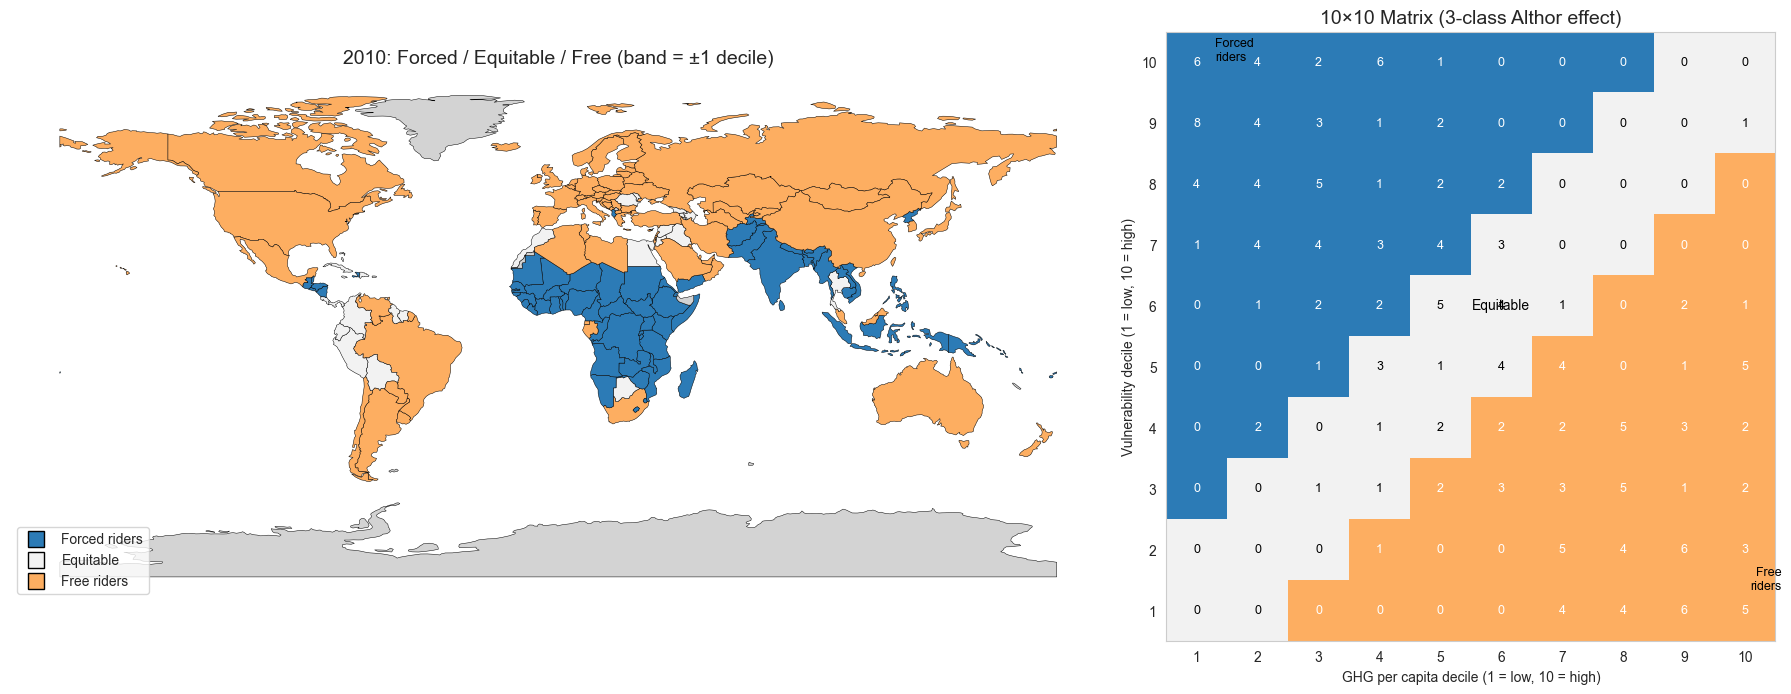

ghg_decile,1,2,3,4,5,6,7,8,9,10
vuln_decile,,,,,,,,,,
1,0,0,0,0,0,0,4,4,6,5
2,0,0,0,1,0,0,5,4,6,3
3,0,0,1,1,2,3,3,5,1,2
4,0,2,0,1,2,2,2,5,3,2
5,0,0,1,3,1,4,4,0,1,5
6,0,1,2,2,5,4,1,0,2,1
7,1,4,4,3,4,3,0,0,0,0
8,4,4,5,1,2,2,0,0,0,0
9,8,4,3,1,2,0,0,0,0,1


In [17]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


def add_deciles_quantile(dfy: pd.DataFrame, col: str, n_bins: int = 10) -> pd.Series:
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


def compute_deciles(dfy: pd.DataFrame) -> pd.DataFrame:
    """
    Annahme: Vulnerability ist so orientiert, dass hohe Werte = hohe Vulnerabilität.
    """
    dfy = dfy.copy()
    dfy["ghg_decile"] = add_deciles_quantile(dfy, "GHG_per_capita", 10)   # 1..10
    dfy["vuln_decile"] = add_deciles_quantile(dfy, "Vulnerability", 10)   # 1..10
    return dfy


def build_count_matrix_10x10(dfy: pd.DataFrame) -> pd.DataFrame:
    mat = (
        dfy.pivot_table(
            index="vuln_decile",
            columns="ghg_decile",
            values="ISO3",
            aggfunc="nunique",
            fill_value=0
        )
        .reindex(index=range(1, 11), columns=range(1, 11), fill_value=0)
        .astype(int)
    )
    return mat


def build_class_grid_10x10(band: int = 1) -> np.ndarray:
    """
    Liefert ein 10×10 Grid mit Klassen:
      0 = forced rider (vuln >> ghg)  -> d = vuln - ghg > band
      1 = equitable (nahe Diagonale)  -> |d| <= band
      2 = free rider (ghg >> vuln)    -> d = vuln - ghg < -band
    """
    grid = np.zeros((10, 10), dtype=int)
    for i in range(10):       # vuln index
        for j in range(10):   # ghg index
            d = (i + 1) - (j + 1)  # vuln - ghg
            if abs(d) <= band:
                grid[i, j] = 1  # equitable
            elif d > band:
                grid[i, j] = 0  # forced
            else:
                grid[i, j] = 2  # free
    return grid


def classify_country_rows(dfy: pd.DataFrame, band: int = 1) -> pd.DataFrame:
    """
    Klassifiziert jedes Land in forced/equitable/free basierend auf d = vuln_decile - ghg_decile.
    Output-Spalte: equity_class (0/1/2 wie oben)
    """
    dfy = dfy.copy()
    d = (dfy["vuln_decile"] - dfy["ghg_decile"]).astype(int)

    dfy["equity_class"] = np.where(
        d > band, 0,
        np.where(d < -band, 2, 1)
    ).astype(int)

    return dfy


def plot_map_and_matrix_10x10_3class(
    df_2010: pd.DataFrame,
    year: int = 2010,
    band: int = 1,
    world_url: str = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip",
) -> tuple[pd.DataFrame, gpd.GeoDataFrame]:

    # --- Prep ---
    dfy = compute_deciles(df_2010)
    dfy = classify_country_rows(dfy, band=band)
    counts = build_count_matrix_10x10(dfy)

    class_grid = build_class_grid_10x10(band=band)

    # --- Colorblind 3-class palette (Blau – Hellgrau – Orange) ---
    # forced = blue, equitable = light grey, free = orange
    cmap3 = ListedColormap(["#2C7BB6", "#F2F2F2", "#FDAE61"])
    norm3 = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5], ncolors=3)

    # --- Merge geometry ---
    world = gpd.read_file(world_url)
    world_merged = world.merge(dfy, left_on="ISO_A3_EH", right_on="ISO3", how="left")

    # --- Plot layout ---
    fig, (ax_map, ax_mat) = plt.subplots(
        1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.8, 1]}
    )

    # --- A) Map (3 categories) ---
    world_merged.plot(
        column="equity_class",
        ax=ax_map,
        cmap=cmap3,
        norm=norm3,
        edgecolor="black",
        linewidth=0.35,
        missing_kwds={"color": "lightgrey"},
        legend=False
    )
    ax_map.set_title(f"{year}: Forced / Equitable / Free (band = ±{band} decile)", fontsize=14)
    ax_map.axis("off")

    # Manuelle Legend (klarer als GeoPandas colorbar)
    legend_labels = ["Forced riders", "Equitable", "Free riders"]
    legend_handles = [
        plt.Line2D([0], [0], marker="s", linestyle="", markersize=12,
                   markerfacecolor=cmap3(i), markeredgecolor="black")
        for i in range(3)
    ]
    ax_map.legend(legend_handles, legend_labels, loc="lower left", frameon=True)

    # --- B) Matrix (gleiches 3-class Schema) ---
    im = ax_mat.imshow(
        class_grid,
        cmap=cmap3,
        norm=norm3,
        origin="lower",
        interpolation="none",
        resample=False,
        aspect="equal"
    )

    ax_mat.set_title("10×10 Matrix (3-class Althor effect)", fontsize=14)
    ax_mat.set_xlabel("GHG per capita decile (1 = low, 10 = high)")
    ax_mat.set_ylabel("Vulnerability decile (1 = low, 10 = high)")
    ax_mat.set_xticks(np.arange(10))
    ax_mat.set_yticks(np.arange(10))
    ax_mat.set_xticklabels(range(1, 11))
    ax_mat.set_yticklabels(range(1, 11))
    ax_mat.grid(False)
    ax_mat.minorticks_off()

    # Zellzahlen (Counts) einzeichnen
    # Textfarbe: auf blau/orange weiss, auf grau schwarz
    for i in range(10):
        for j in range(10):
            val = int(counts.iat[i, j])
            cls = class_grid[i, j]
            txt_color = "black" if cls == 1 else "white"
            ax_mat.text(j, i, str(val), ha="center", va="center", color=txt_color, fontsize=9)

    # Optional: Labels wie im Paper
    # Free rider = high GHG (rechts) + low vuln (unten) => bottom-right Bereich
    # Forced rider = low GHG (links) + high vuln (oben) => top-left Bereich
    ax_mat.text(0.3, 9.4, "Forced\nriders", ha="left", va="top", fontsize=9, color="black")
    ax_mat.text(9.6, 0.3, "Free\nriders", ha="right", va="bottom", fontsize=9, color="black")
    ax_mat.text(5.0, 5.0, "Equitable", ha="center", va="center", fontsize=10, color="black")

    plt.tight_layout()
    plt.show()

    return counts, world_merged


# --- RUN ---
# band:
#   0 = nur exakte Diagonale ist equitable
#   1 = Diagonale ±1 ist equitable (empfohlen, wirkt wie "Band" im Paper)
counts_10x10, world_merged_2010 = plot_map_and_matrix_10x10_3class(
    df_2010=merged_df_2010_mapped,
    year=2010,
    band=1
)

counts_10x10


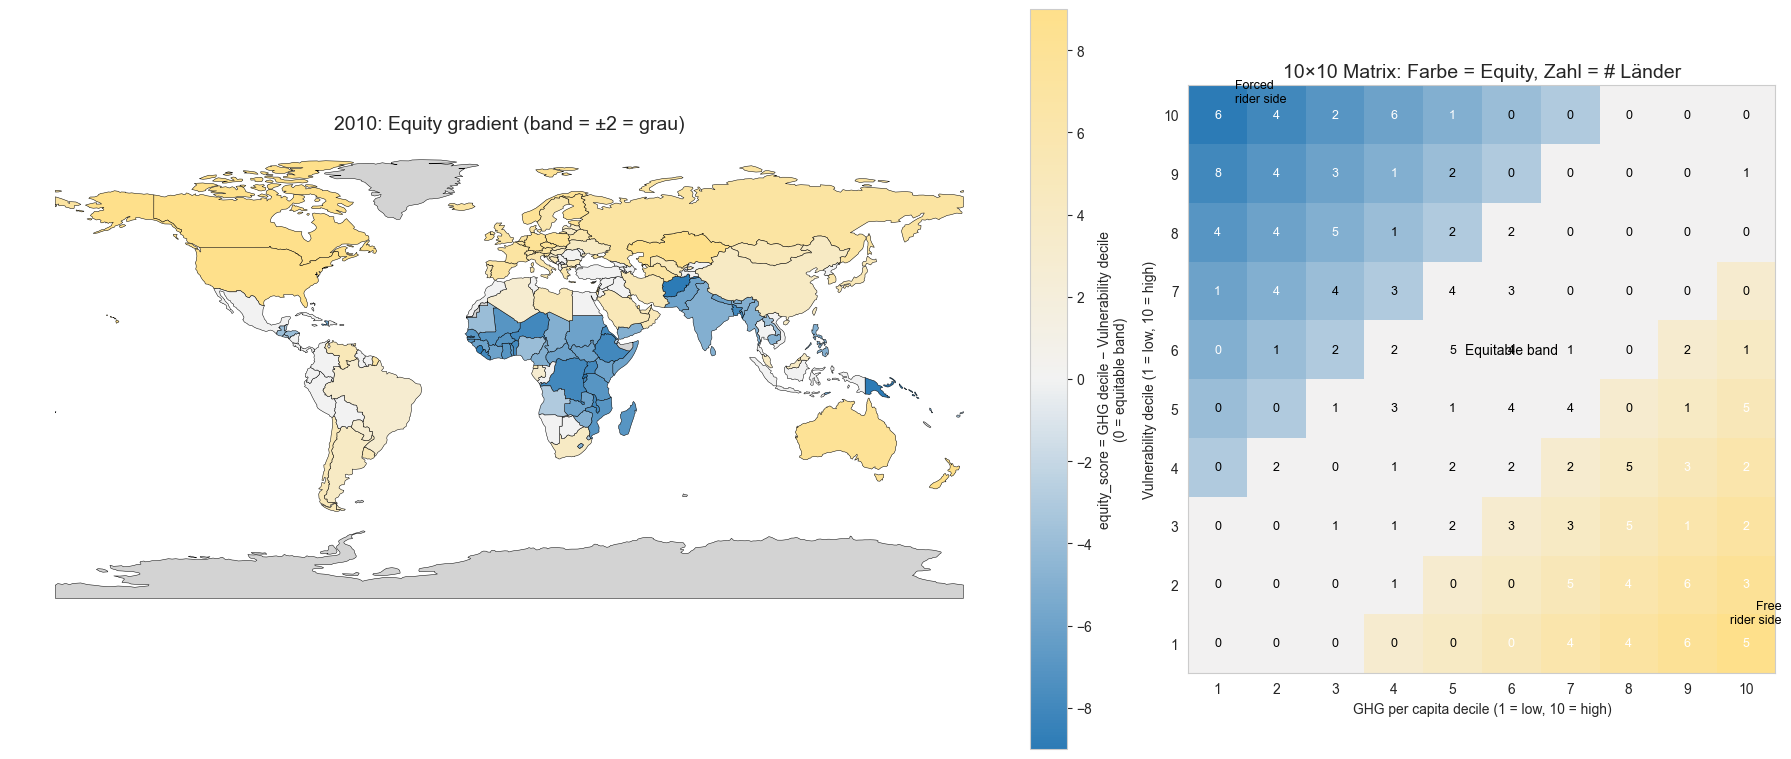

ghg_decile,1,2,3,4,5,6,7,8,9,10
vuln_decile,,,,,,,,,,
1,0,0,0,0,0,0,4,4,6,5
2,0,0,0,1,0,0,5,4,6,3
3,0,0,1,1,2,3,3,5,1,2
4,0,2,0,1,2,2,2,5,3,2
5,0,0,1,3,1,4,4,0,1,5
6,0,1,2,2,5,4,1,0,2,1
7,1,4,4,3,4,3,0,0,0,0
8,4,4,5,1,2,2,0,0,0,0
9,8,4,3,1,2,0,0,0,0,1


In [18]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


def add_deciles_quantile(dfy: pd.DataFrame, col: str, n_bins: int = 10) -> pd.Series:
    return pd.qcut(
        dfy[col].rank(method="first"),
        q=n_bins,
        labels=list(range(1, n_bins + 1))
    ).astype(int)


def compute_deciles(dfy: pd.DataFrame) -> pd.DataFrame:
    dfy = dfy.copy()
    dfy["ghg_decile"] = add_deciles_quantile(dfy, "GHG_per_capita", 10)   # 1..10
    dfy["vuln_decile"] = add_deciles_quantile(dfy, "Vulnerability", 10)   # 1..10
    return dfy


def build_count_matrix_10x10(dfy: pd.DataFrame) -> pd.DataFrame:
    return (
        dfy.pivot_table(
            index="vuln_decile",
            columns="ghg_decile",
            values="ISO3",
            aggfunc="nunique",
            fill_value=0
        )
        .reindex(index=range(1, 11), columns=range(1, 11), fill_value=0)
        .astype(int)
    )


def make_blue_grey_yellow_cmap() -> LinearSegmentedColormap:
    # farbblind-tauglich, klarer Kontrast: Blau -> Grau -> Gelb
    # (du kannst die 3 Farben jederzeit fein-tunen)
    return LinearSegmentedColormap.from_list(
        "blue_grey_yellow",
        ["#2C7BB6", "#F2F2F2", "#FEE08B"],  # blue, grey, yellow
        N=256
    )


def add_equity_score(dfy: pd.DataFrame, band: int = 1) -> pd.DataFrame:
    """
    score = ghg_decile - vuln_decile
      score > 0  -> Free-rider Richtung (hohe GHG, tiefere Vulnerability)
      score < 0  -> Forced-rider Richtung (tiefe GHG, höhere Vulnerability)
      |score| <= band -> Equitable-Band (score = 0)
    """
    dfy = dfy.copy()
    diff = (dfy["ghg_decile"] - dfy["vuln_decile"]).astype(int)
    dfy["equity_score"] = np.where(np.abs(diff) <= band, 0, diff).astype(int)
    return dfy


def build_score_grid_10x10(band: int = 1) -> np.ndarray:
    """
    Liefert ein 10x10 Grid mit equity_score pro Zelle (nicht counts!),
    damit die inset-Matrix exakt die gleiche Farb-Logik wie die Karte hat.
    """
    grid = np.zeros((10, 10), dtype=int)
    for i in range(10):       # vuln decile = i+1 (y)
        for j in range(10):   # ghg  decile = j+1 (x)
            diff = (j + 1) - (i + 1)  # ghg - vuln
            grid[i, j] = 0 if abs(diff) <= band else diff
    return grid


def plot_map_and_matrix_10x10_equity_gradient(
    df_2010: pd.DataFrame,
    year: int = 2010,
    band: int = 1,
    world_url: str = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip",
) -> tuple[pd.DataFrame, gpd.GeoDataFrame]:

    # --- Prep ---
    dfy = compute_deciles(df_2010)
    dfy = add_equity_score(dfy, band=band)

    counts = build_count_matrix_10x10(dfy)
    score_grid = build_score_grid_10x10(band=band)

    # max mögliche Distanz in 10 Deciles: 9
    vmax = 9
    vmin = -9

    cmap = make_blue_grey_yellow_cmap()
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    # --- Merge geometry ---
    world = gpd.read_file(world_url)
    world_merged = world.merge(dfy, left_on="ISO_A3_EH", right_on="ISO3", how="left")

    # --- Layout ---
    fig, (ax_map, ax_mat) = plt.subplots(
        1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.8, 1]}
    )

    # --- A) Map (equity_score) ---
    world_merged.plot(
        column="equity_score",
        ax=ax_map,
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidth=0.35,
        missing_kwds={"color": "lightgrey"},
        legend=False
    )
    ax_map.set_title(f"{year}: Equity gradient (band = ±{band} = grau)", fontsize=14)
    ax_map.axis("off")

    # Colorbar (für Richtung + Stärke)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax_map, fraction=0.035, pad=0.02)
    cbar.set_label("equity_score = GHG decile − Vulnerability decile\n(0 = equitable band)", fontsize=10)

    # --- B) 10×10 Matrix: Farbe = equity_score, Zahl = count ---
    im = ax_mat.imshow(
        score_grid,
        cmap=cmap,
        norm=norm,
        origin="lower",
        interpolation="none",
        resample=False,
        aspect="equal"
    )

    ax_mat.set_title("10×10 Matrix: Farbe = Equity, Zahl = # Länder", fontsize=14)
    ax_mat.set_xlabel("GHG per capita decile (1 = low, 10 = high)")
    ax_mat.set_ylabel("Vulnerability decile (1 = low, 10 = high)")
    ax_mat.set_xticks(np.arange(10))
    ax_mat.set_yticks(np.arange(10))
    ax_mat.set_xticklabels(range(1, 11))
    ax_mat.set_yticklabels(range(1, 11))
    ax_mat.grid(False)
    ax_mat.minorticks_off()

    # Zellzahlen (Counts) einzeichnen
    # Textfarbe passend zum Hintergrund:
    # - im grauen Band: schwarz
    # - sonst: weiss, wenn |score| gross (dunkler), sonst schwarz (heller)
    for i in range(10):
        for j in range(10):
            val = int(counts.iat[i, j])
            sc = int(score_grid[i, j])

            if sc == 0:
                txt_color = "black"
            else:
                # einfache Heuristik: weiter weg von 0 -> eher weiss
                txt_color = "white" if abs(sc) >= 5 else "black"

            ax_mat.text(j, i, str(val), ha="center", va="center", color=txt_color, fontsize=9)

    # Orientierungstext (wie Paper-Feeling)
    ax_mat.text(0.3, 9.6, "Forced\nrider side", ha="left", va="top", fontsize=9, color="black")
    ax_mat.text(9.6, 0.3, "Free\nrider side", ha="right", va="bottom", fontsize=9, color="black")
    ax_mat.text(5.0, 5.0, "Equitable band", ha="center", va="center", fontsize=10, color="black")

    plt.tight_layout()
    plt.show()

    return counts, world_merged


# --- RUN ---
# band=1 oder band=2 gibt meist den “breiten grauen Streifen” Effekt wie du ihn magst.
counts_10x10, world_merged_2010 = plot_map_and_matrix_10x10_equity_gradient(
    df_2010=merged_df_2010_mapped,
    year=2010,
    band=2
)

counts_10x10
